# 2.6 概率

## 多项式分布

**多项式分布（Multinomial Distribution）**
多项式分布是二项分布的推广，描述了一组独立试验中多个可能结果的概率分布。例如，掷骰子 $n$ 次，每个面朝上的次数符合多项式分布。

---

**1. 公式**
假设我们有一个包含 $k$ 个可能类别的离散随机变量，每次试验中，每个类别的出现概率分别为：
$$
    \mathbf{p} = (p_1, p_2, \dots, p_k), \quad \sum_{i=1}^{k} p_i = 1
$$
进行 $n$ 次独立试验后，得到各类别的计数 $\mathbf{x} = (x_1, x_2, \dots, x_k)$，满足：
$$
    \sum_{i=1}^{k} x_i = n
$$
则多项式分布的概率质量函数（PMF）为：
$$
    P(X_1 = x_1, X_2 = x_2, \dots, X_k = x_k) = \frac{n!}{x_1! x_2! \dots x_k!} p_1^{x_1} p_2^{x_2} \dots p_k^{x_k}
$$
其中：
- $n! / (x_1! x_2! \dots x_k!)$ 是组合数，表示在 $n$ 次试验中，有 $x_1, x_2, ..., x_k$ 次出现各类别的排列方式。
- $p_1^{x_1} p_2^{x_2} \dots p_k^{x_k}$ 是各类别按给定次数出现的概率。

---

**2. 多项式分布的性质**
- **期望值**：
$$
    E[X_i] = n p_i
$$
- **方差**：
$$
    \text{Var}(X_i) = n p_i (1 - p_i)
$$
- **协方差**：
$$
    \text{Cov}(X_i, X_j) = -n p_i p_j, \quad (i \neq j)
$$
说明不同类别的计数是负相关的。

---




In [10]:
import numpy as np
import math

In [11]:
n=10 #n次试验
p=[0.2,0.3,0.5]

sample=np.random.multinomial(n,p,size=math.floor(1e5))# size次的采样次数

sample.shape,sample

((100000, 3),
 array([[2, 3, 5],
        [1, 5, 4],
        [2, 2, 6],
        ...,
        [4, 3, 3],
        [3, 1, 6],
        [3, 2, 5]]))

In [12]:
for i in np.arange(3):
    print(sample[:,i].mean())


1.99801
2.99666
5.00533


In [13]:
sample.mean(axis=0)

array([1.99801, 2.99666, 5.00533])

In [16]:
sample.sum(axis=0)

array([199801, 299666, 500533])

这个求平均是这样的

sample的shape是（size，3），然后我要求每个类别的平均，我们对sample的第0维度求平均:

[[sample_1],[sample_2],...,[sample_size]].mean(axis=0)=[sample_1+...+sample_size/size]



`samples` 的形状是 `(size, 3)`，每一行代表一次试验的结果（共 `n` 次试验，每个类别的计数不同），每一列代表某个类别在 `size` 次试验中的分布情况。  

```python
expected_counts = np.mean(samples, axis=0)
```
这里 `axis=0` 表示沿着第 0 维度（行方向）求平均值，即：
$$
    \mathbb{E}[X_i] = \frac{1}{\text{size}} \sum_{j=1}^{\text{size}} \text{samples}[j, i]
$$
这样就得到了每个类别的 **实验均值**，理论上应该接近 $n \cdot p_i$。

你的表达：
$$
    [\text{sample}_1, \text{sample}_2, ..., \text{sample}_{\text{size}}].\text{mean}(axis=0) = \frac{\sum_{i=1}^{\text{size}} \text{sample}_i}{\text{size}}
$$
和 numpy 的 `np.mean(samples, axis=0)` 计算逻辑完全一致。  





绘制直方图

In [14]:
import matplotlib.pyplot as plt

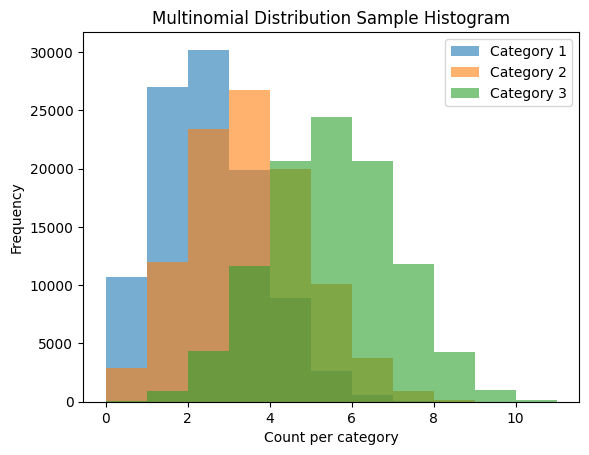

In [18]:
# 统计每个类别的出现次数 bin是横坐标的最大值
plt.hist(sample[:, 0], bins=range(n+2), alpha=0.6, label="Category 1")
plt.hist(sample[:, 1], bins=range(n+2), alpha=0.6, label="Category 2")
plt.hist(sample[:, 2], bins=range(n+2), alpha=0.6, label="Category 3")

plt.xlabel("Count per category")
plt.ylabel("Frequency")
plt.legend()
plt.title("Multinomial Distribution Sample Histogram")
plt.show()
